# Neural Network Experiments — NLP
This notebook extends the basic neural network with NLP features.
Tweet text is embedded via TF-IDF and fed into a wide first layer alongside
numeric user/tweet features. Run cells in order from top to bottom.

In [39]:
import os
import numpy as np
import pandas as pd
import scipy.sparse as sp

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MaxAbsScaler
from sklearn.feature_extraction.text import TfidfVectorizer

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

import importlib
import preprocessing_NLP
importlib.reload(preprocessing_NLP)
from preprocessing_NLP import build_raw_dataset_nlp

BASE_DIR = "datasets_full.csv/datasets_full.csv"
USERS_FILE = "users.csv"
TWEETS_FILE = "tweets.csv"

DATASETS = {
    "genuine_accounts.csv": 0,
    "fake_followers.csv": 1,
    "social_spambots_1.csv": 1,
    "social_spambots_2.csv": 1,
    "social_spambots_3.csv": 1,
    "traditional_spambots_1.csv": 1,
    "traditional_spambots_2.csv": 1,
    "traditional_spambots_3.csv": 1,
    "traditional_spambots_4.csv": 1,
}

TEXT_COLUMN = "text"

USER_FEATURES = [
    "statuses_count", "followers_count", "friends_count",
    "favourites_count", "listed_count", "default_profile",
    "default_profile_image", "verified"
]

TWEET_FEATURES = [
   "text", "reply_count", "favorite_count", "num_urls", "num_mentions"
]

# TF-IDF settings
TFIDF_PARAMS = {
    "max_features": 2000,
    "ngram_range": (1, 2),
    "stop_words": "english",
    "sublinear_tf": True,
}

# Neural network hyperparameters
NN_PARAMS = {
    # Two-branch architecture: numeric branch + text branch, then merged
    "num_hidden": [64, 32],       # numeric feature branch hidden dims
    "text_hidden": [256, 64],     # TF-IDF text branch hidden dims
    "merged_hidden": [128, 64],   # merged trunk hidden dims
    "dropout": 0.3,
    "learning_rate": 1e-3,
    "batch_size": 256,
    "epochs": 50,
    "patience": 7,
    "random_state": 42,
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dataset root:", BASE_DIR)
print("Files configured:", len(DATASETS))
print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)

Dataset root: datasets_full.csv/datasets_full.csv
Files configured: 9
PyTorch version: 2.11.0
Device: cpu


In [40]:
class DualBranchBotDetector(nn.Module):

    def __init__(self, num_input_dim, text_input_dim,
                 num_hidden, text_hidden, merged_hidden, dropout):
        super().__init__()

        def make_branch(in_dim, hidden_dims):
            layers = []
            for h in hidden_dims:
                layers += [
                    nn.Linear(in_dim, h),
                    nn.BatchNorm1d(h),
                    nn.ReLU(),
                    nn.Dropout(dropout),
                ]
                in_dim = h
            return nn.Sequential(*layers), in_dim

        self.num_branch, num_out = make_branch(num_input_dim, num_hidden)
        self.text_branch, text_out = make_branch(text_input_dim, text_hidden)

        merged_in = num_out + text_out
        trunk_layers = []
        for h in merged_hidden:
            trunk_layers += [
                nn.Linear(merged_in, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            merged_in = h
        trunk_layers.append(nn.Linear(merged_in, 1))
        self.trunk = nn.Sequential(*trunk_layers)

    def forward(self, x_num, x_text):
        n = self.num_branch(x_num)
        t = self.text_branch(x_text)
        return self.trunk(torch.cat([n, t], dim=1)).squeeze(1)

In [41]:
# Block 1: Data loading (full configured datasets)
raw = build_raw_dataset_nlp(
    DATASETS,
    BASE_DIR,
    TWEET_FEATURES,
    TWEETS_FILE
)

Loaded genuine_accounts.csv: 3,474 rows
Loaded fake_followers.csv: 3,351 rows
Loaded social_spambots_1.csv: 991 rows
Loaded social_spambots_2.csv: 3,457 rows
Loaded social_spambots_3.csv: 464 rows
Loaded traditional_spambots_1.csv: 1,000 rows
Loaded traditional_spambots_2.csv: 100 rows
Loaded traditional_spambots_3.csv: 403 rows
Loaded traditional_spambots_4.csv: 1,128 rows

Total rows loaded: 14,368


In [42]:
# Block 2: Slicing and preprocessing
available_numeric = [c for c in USER_FEATURES if c in raw.columns]
if not available_numeric:
    raise ValueError("No numeric feature columns found in raw data.")

X = raw[available_numeric].copy()
X = X.apply(pd.to_numeric, errors="coerce")

numeric_tweet_features = [c for c in TWEET_FEATURES if c != "text" and c in raw.columns]
X = pd.concat([X, raw[numeric_tweet_features]], axis=1)
X = X.fillna(0)

if "text" in raw.columns:
    X["text"] = raw["text"].fillna("").astype(str)

y = raw["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=NN_PARAMS["random_state"], stratify=y
)

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
pos_weight = torch.tensor([neg_count / pos_count], dtype=torch.float32).to(DEVICE)

print("Numeric features:", [c for c in X.columns if c != "text"])
print("Shape:", X.shape)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Class balance:\n", y.value_counts(dropna=False))
print(f"pos_weight (BCEWithLogitsLoss): {pos_weight.item():.4f}")

Numeric features: ['statuses_count', 'followers_count', 'friends_count', 'favourites_count', 'listed_count', 'default_profile', 'default_profile_image', 'verified', 'reply_count', 'favorite_count', 'num_urls', 'num_mentions']
Shape: (14368, 13)
Train shape: (11494, 13)
Test shape: (2874, 13)
Class balance:
 label
1    10894
0     3474
Name: count, dtype: int64
pos_weight (BCEWithLogitsLoss): 0.3189


In [43]:
# Block 3: Feature engineering — TF-IDF + scaled numerics
tfidf = TfidfVectorizer(**TFIDF_PARAMS)
text_train_sparse = tfidf.fit_transform(X_train["text"])
text_test_sparse  = tfidf.transform(X_test["text"])

num_cols = [c for c in X_train.columns if c != "text"]
X_train_num = X_train[num_cols].values.astype(np.float32)
X_test_num  = X_test[num_cols].values.astype(np.float32)

# MaxAbsScaler keeps sparse-friendly range while matching TF-IDF scale
scaler = MaxAbsScaler()
X_train_num = scaler.fit_transform(X_train_num)
X_test_num  = scaler.transform(X_test_num)

# Convert sparse TF-IDF to dense float32 tensors
X_train_text = text_train_sparse.toarray().astype(np.float32)
X_test_text  = text_test_sparse.toarray().astype(np.float32)

tfidf_feature_names = [f"tfidf_{w}" for w in tfidf.get_feature_names_out()]
all_feature_names = num_cols + tfidf_feature_names

print(f"Numeric feature matrix: {X_train_num.shape}")
print(f"TF-IDF feature matrix:  {X_train_text.shape}")

Numeric feature matrix: (11494, 12)
TF-IDF feature matrix:  (11494, 84)


In [44]:
# Block 4: Training
torch.manual_seed(NN_PARAMS["random_state"])

X_tr_num_t  = torch.tensor(X_train_num,  dtype=torch.float32)
X_tr_text_t = torch.tensor(X_train_text, dtype=torch.float32)
y_tr_t      = torch.tensor(y_train.values, dtype=torch.float32)

X_te_num_t  = torch.tensor(X_test_num,  dtype=torch.float32)
X_te_text_t = torch.tensor(X_test_text, dtype=torch.float32)
y_te_t      = torch.tensor(y_test.values, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_tr_num_t, X_tr_text_t, y_tr_t),
    batch_size=NN_PARAMS["batch_size"],
    shuffle=True,
)

model = DualBranchBotDetector(
    num_input_dim=X_train_num.shape[1],
    text_input_dim=X_train_text.shape[1],
    num_hidden=NN_PARAMS["num_hidden"],
    text_hidden=NN_PARAMS["text_hidden"],
    merged_hidden=NN_PARAMS["merged_hidden"],
    dropout=NN_PARAMS["dropout"],
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=NN_PARAMS["learning_rate"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

best_val_loss = float("inf")
patience_counter = 0
best_state = None

X_te_num_dev  = X_te_num_t.to(DEVICE)
X_te_text_dev = X_te_text_t.to(DEVICE)
y_te_dev      = y_te_t.to(DEVICE)

for epoch in range(1, NN_PARAMS["epochs"] + 1):
    model.train()
    train_loss = 0.0
    for xb_num, xb_text, yb in train_loader:
        xb_num  = xb_num.to(DEVICE)
        xb_text = xb_text.to(DEVICE)
        yb      = yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb_num, xb_text), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(xb_num)
    train_loss /= len(X_tr_num_t)

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_te_num_dev, X_te_text_dev), y_te_dev).item()
    scheduler.step(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= NN_PARAMS["patience"]:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

model.load_state_dict(best_state)
print("\nTraining complete. Best val_loss:", round(best_val_loss, 4))

Epoch   1 | train_loss=0.2837  val_loss=0.2500
Epoch  10 | train_loss=0.1333  val_loss=0.1432
Epoch  20 | train_loss=0.1134  val_loss=0.1043
Epoch  30 | train_loss=0.0995  val_loss=0.1063
Epoch  40 | train_loss=0.0953  val_loss=0.0824
Epoch  50 | train_loss=0.0976  val_loss=0.0809

Training complete. Best val_loss: 0.0758


In [45]:
# Block 5: Evaluation
model.eval()
with torch.no_grad():
    logits = model(X_te_num_t.to(DEVICE), X_te_text_t.to(DEVICE)).cpu()
    pred_proba = torch.sigmoid(logits).numpy()
    pred = (pred_proba >= 0.5).astype(int)

print(f"accuracy:          {accuracy_score(y_test, pred):.4f}")
print(f"balanced_accuracy: {balanced_accuracy_score(y_test, pred):.4f}")
print(f"f1_macro:          {f1_score(y_test, pred, average='macro'):.4f}")
print(f"roc_auc:           {roc_auc_score(y_test, pred_proba):.4f}")
print(f"AUPRC:             {average_precision_score(y_test, pred_proba):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))
print("\nClassification Report:")
print(classification_report(y_test, pred, digits=4))

accuracy:          0.9520
balanced_accuracy: 0.9380
f1_macro:          0.9350
roc_auc:           0.9901
AUPRC:             0.9969

Confusion Matrix:
[[ 633   62]
 [  76 2103]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8928    0.9108    0.9017       695
           1     0.9714    0.9651    0.9682      2179

    accuracy                         0.9520      2874
   macro avg     0.9321    0.9380    0.9350      2874
weighted avg     0.9524    0.9520    0.9521      2874



In [46]:
# Block 6: Feature importance via input-gradient saliency
model.eval()

X_te_num_grad  = X_te_num_t.to(DEVICE).requires_grad_(True)
X_te_text_grad = X_te_text_t.to(DEVICE).requires_grad_(True)

logits_grad = model(X_te_num_grad, X_te_text_grad)
loss_grad = criterion(logits_grad, y_te_t.to(DEVICE))
loss_grad.backward()

num_saliency  = X_te_num_grad.grad.abs().mean(dim=0).cpu().numpy()
text_saliency = X_te_text_grad.grad.abs().mean(dim=0).cpu().numpy()

all_saliency = np.concatenate([num_saliency, text_saliency])

importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "saliency": all_saliency,
}).sort_values("saliency", ascending=False)

print("Top 20 Features — Neural Network NLP (gradient saliency):")
display(importance_df.head(20))

Top 20 Features — Neural Network NLP (gradient saliency):


,feature,saliency
3,favourites_count,0.012042
0,statuses_count,0.007360
4,listed_count,0.003475
1,followers_count,0.001687
10,num_urls,0.001302
2,friends_count,0.001163
8,reply_count,0.000989
11,num_mentions,0.000617
16,tfidf_13,0.000186
7,verified,0.000169


In [47]:
# Block 7: Feature importance list
print("Top 20 Features — Neural Network NLP (gradient saliency):")
for i, row in enumerate(importance_df.head(20).itertuples(), 1):
    print(f"  {i:2}. {row.feature:<35} {row.saliency:.6f}")

Top 20 Features — Neural Network NLP (gradient saliency):
   1. favourites_count                    0.012042
   2. statuses_count                      0.007360
   3. listed_count                        0.003475
   4. followers_count                     0.001687
   5. num_urls                            0.001302
   6. friends_count                       0.001163
   7. reply_count                         0.000989
   8. num_mentions                        0.000617
   9. tfidf_13                            0.000186
  10. verified                            0.000169
  11. favorite_count                      0.000133
  12. tfidf_307 306                       0.000125
  13. tfidf_179 180                       0.000114
  14. tfidf_309                           0.000101
  15. tfidf_2083038                       0.000099
  16. tfidf_310                           0.000098
  17. tfidf_194                           0.000093
  18. tfidf_156                           0.000091
  19. tfidf_21          

In [48]:
# Block 8: Save model
MODEL_PATH = "nn_nlp_bot_detector.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "num_input_dim": X_train_num.shape[1],
    "text_input_dim": X_train_text.shape[1],
    "num_hidden": NN_PARAMS["num_hidden"],
    "text_hidden": NN_PARAMS["text_hidden"],
    "merged_hidden": NN_PARAMS["merged_hidden"],
    "dropout": NN_PARAMS["dropout"],
    "num_feature_names": num_cols,
    "tfidf_vocab": tfidf.vocabulary_,
    "tfidf_params": TFIDF_PARAMS,
    "scaler_scale": scaler.scale_.tolist(),
}, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to nn_nlp_bot_detector.pt


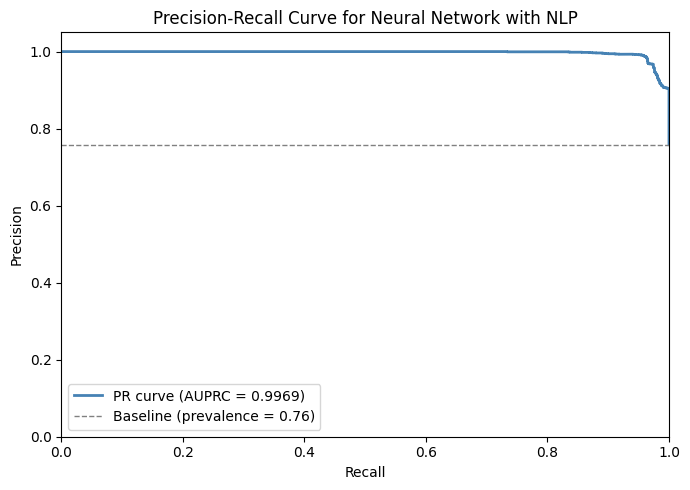

In [52]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, pred_proba)
auprc = average_precision_score(y_test, pred_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color="steelblue", lw=2, label=f"PR curve (AUPRC = {auprc:.4f})")
ax.axhline(y=y_test.mean(), color="gray", linestyle="--", lw=1, label=f"Baseline (prevalence = {y_test.mean():.2f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve for Neural Network with NLP")
ax.legend(loc="lower left")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

## Run Order
1. Cell 1: imports and constants
2. Cell 2: model definition (DualBranchBotDetector)
3. Cell 3: full data loading
4. Cell 4: slicing and preprocessing
5. Cell 5: TF-IDF + numeric feature engineering
6. Cell 6: training
7. Cell 7: evaluation
8. Cell 8: gradient saliency importance (display)
9. Cell 9: gradient saliency importance (list)
10. Cell 10: save model